In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import zarr

In [2]:
BASEPATH = '/scratch/pa2439/Projects/single_cell_imaging/canvas'

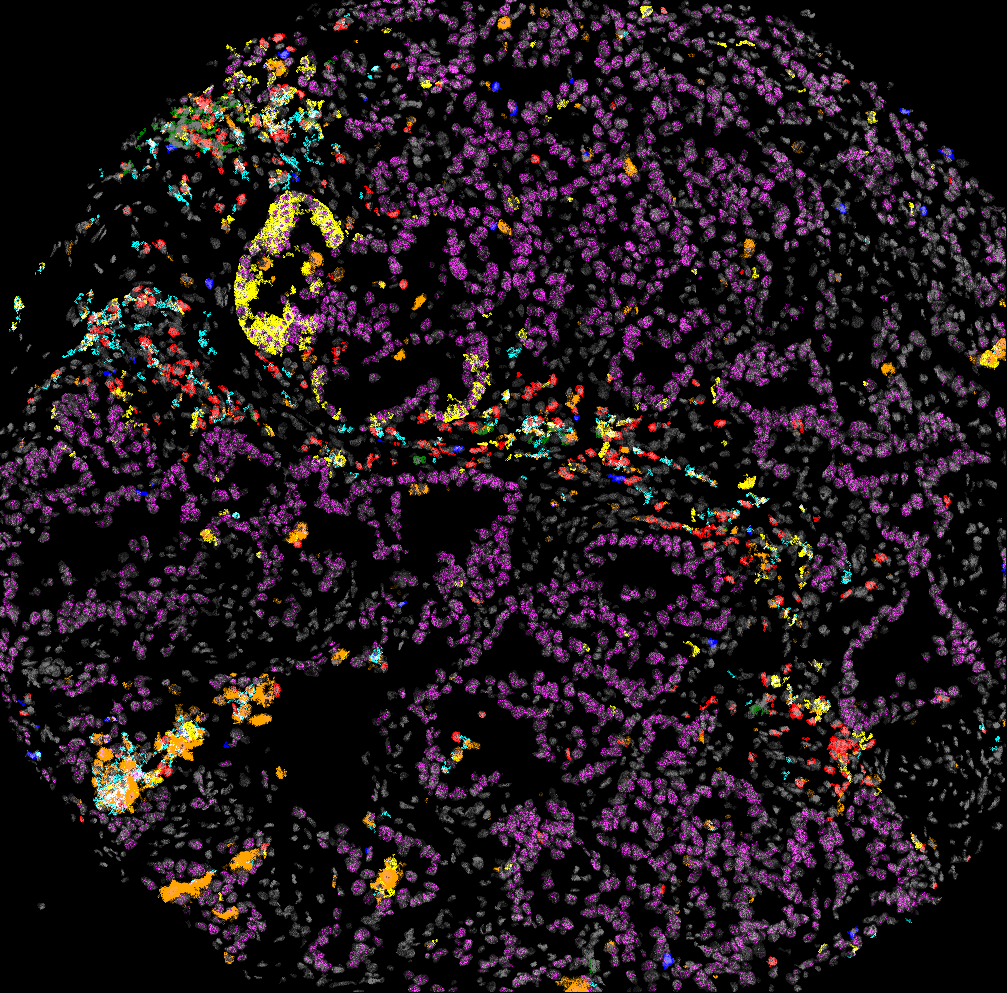

In [3]:
Image(f"{BASEPATH}/canvas_examples/Sorin_2023/data/processed_data/data/LUAD_D010/visualization/sample.png", width=300)

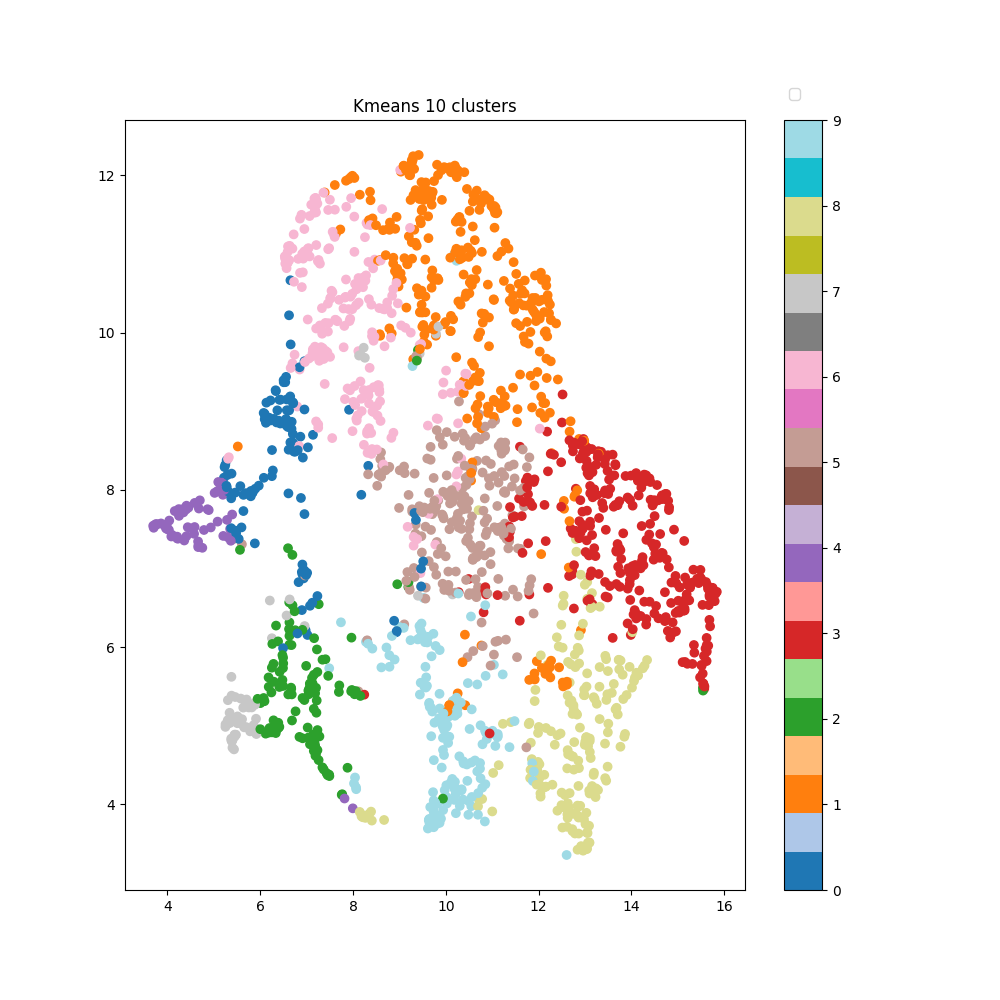

In [4]:
from IPython.display import Image
Image(f'{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/kmeans/10/clusters.png', width=500)

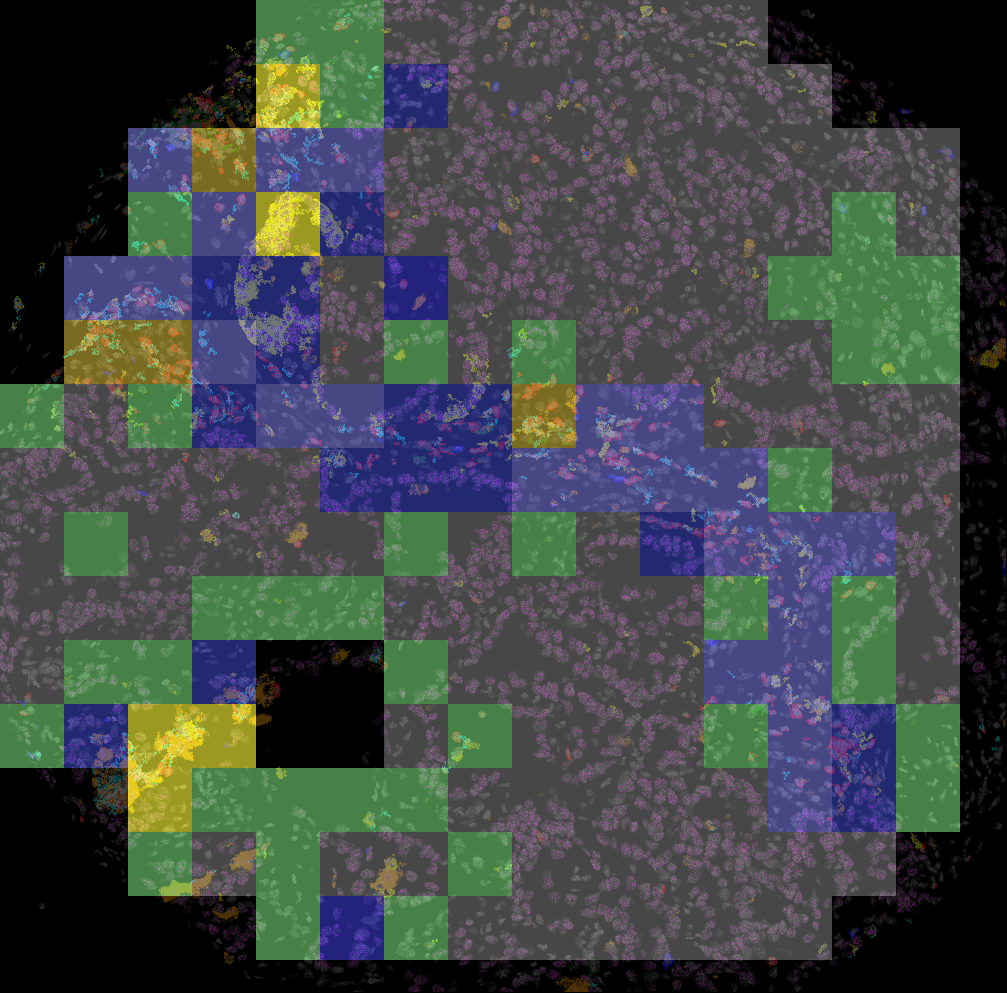

In [5]:
Image(f'{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/sample_visualization/10/LUAD_D010/n_cluster/10/cluster_on_color.png', width=300)

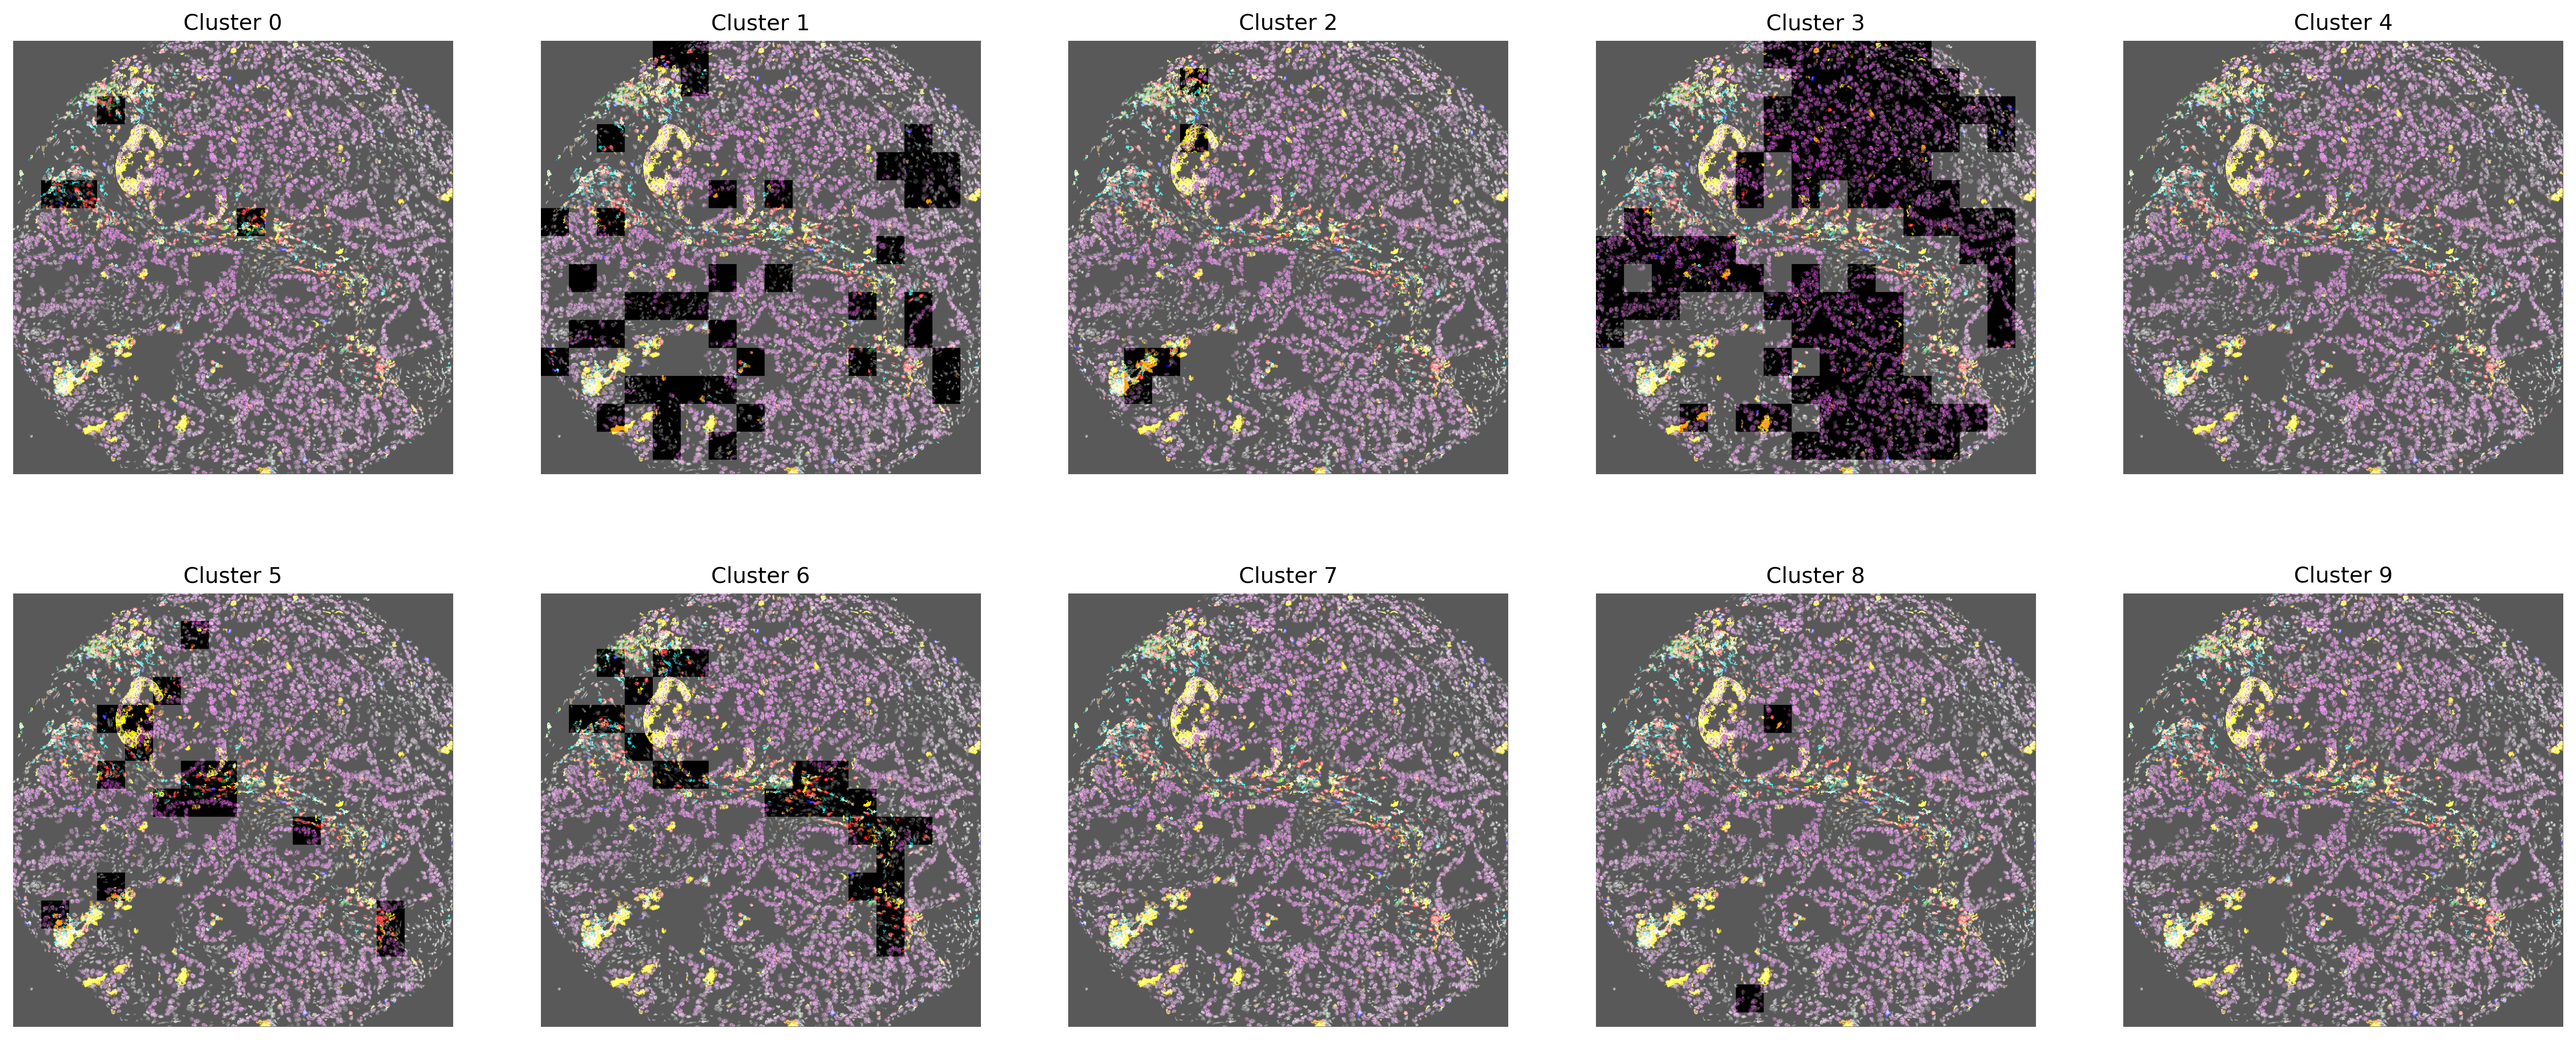

In [6]:
Image(f'{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/sample_visualization/10/LUAD_D010/n_cluster/10/cluster_on_color_by_cluster.png', width=800)

In [7]:
data = np.load(f"{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/tile_embedding/embedding_mean.npy")

In [8]:
data.shape

(1902, 1024)

In [9]:
clusterinfo = np.load("/scratch/pa2439/Projects/single_cell_imaging/canvas/canvas_examples/Sorin_2023/data/analysis/kmeans/10/clusters.npy")

In [10]:
clusterinfo.shape

(1902,)

In [11]:
luad_locs = np.load(f"{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/tile_embedding/tile_location.npy")

In [12]:
luad_name = np.load(f"{BASEPATH}/canvas_examples/Sorin_2023/data/analysis/tile_embedding/sample_name.npy")

In [13]:
luad_tile_dict = {'luad': luad_name, 'x': luad_locs.T[0], 'y': luad_locs.T[1]}
pd.DataFrame(luad_tile_dict)

,luad,x,y
0,LUAD_D002,0,0
1,LUAD_D002,0,64
2,LUAD_D002,0,128
3,LUAD_D002,0,384
4,LUAD_D002,0,448
...,...,...,...
1897,LUAD_D006,896,320
1898,LUAD_D006,896,384
1899,LUAD_D006,896,448
1900,LUAD_D006,896,512


In [15]:
LUAD_PATH = "/scratch/pa2439/Projects/single_cell_imaging/canvas/canvas_examples/Sorin_2023/data/processed_data/data/"

In [16]:
import umap.umap_ as umap
projection = umap.UMAP(n_components=3)
umap_3d_data = projection.fit_transform(data)

projection_2d = umap.UMAP(n_components=2)
umap_2d_data = projection_2d.fit_transform(data)

/ext3/miniconda3/envs/single_cell_conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/ext3/miniconda3/envs/single_cell_conda/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/ext3/miniconda3/envs/single_cell_conda/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [67]:
LUADS = {}
NEW_LUAD = []
EMBEDDINGS = {'index': [], 'name': [], 'position': []}
UMAP_2D = {'index': [], 'name': [], 'position': []}
UMAP_3D = {'index': [], 'name': [], 'position': []}
ORIGINAL_POSITIONS = {'index': [], 'name': [], 'position': []}

offset = {}
dims = [0, 0]
for i, s in enumerate(set(luad_name)):
    LUADS[s] = zarr.open(LUAD_PATH + s + "/data.zarr", mode='r')
    if i == 0:
        offset[s] = [0,0]
    else:
        offset[s] = [dims[0], dims[1]]
        xy = np.shape(LUADS[s])[1:3]
        dims[0] += xy[0]
        dims[1] += xy[1]
    
for i in range(len(luad_name)):
    luad = luad_name[i]
    x = luad_locs[i][0]
    y = luad_locs[i][1]

    # append tile to array
    NEW_LUAD.append(LUADS[luad][:, x:(x+64), y:(y+64)].astype("uint64"))

    # note down index of tile (global)
    EMBEDDINGS['index'].append(i)
    UMAP_2D['index'].append(i)
    UMAP_3D['index'].append(i)
    ORIGINAL_POSITIONS['index'].append(i)

    # note down luad name
    EMBEDDINGS['name'].append(luad)
    UMAP_2D['name'].append(luad)
    UMAP_3D['name'].append(luad)
    ORIGINAL_POSITIONS['name'].append(luad)
    
    # write tile positions/embeddings
    EMBEDDINGS['position'].append(data[i])
    UMAP_2D['position'].append(umap_2d_data[i])
    UMAP_3D['position'].append(umap_3d_data[i])
    ORIGINAL_POSITIONS['position'].append([int(x + offset[luad][0]), int(y + offset[luad][1])])
    

In [58]:
# dump LUADs to zarr
zarr.save("./results/Sorin/LUAD_combined.zarr", np.array(np.moveaxis(NEW_LUAD, 1, 0), dtype="uint16"))

In [70]:
# save data to tsv files
pd.DataFrame(EMBEDDINGS).to_csv("./results/Sorin/luad_embeddings_1024_dim.tsv", sep='\t')
pd.DataFrame(UMAP_2D).to_csv("./results/Sorin/luad_embeddings_umap_2_dim.tsv", sep='\t')
pd.DataFrame(UMAP_3D).to_csv("./results/Sorin/luad_embeddings_umap_3_dim.tsv", sep='\t')
pd.DataFrame(ORIGINAL_POSITIONS).to_csv("./results/Sorin/luad_tile_positions_2_dim.tsv", sep='\t')

In [15]:
x = zarr.open("./results/Sorin/LUAD_combined.zarr", mode='r')

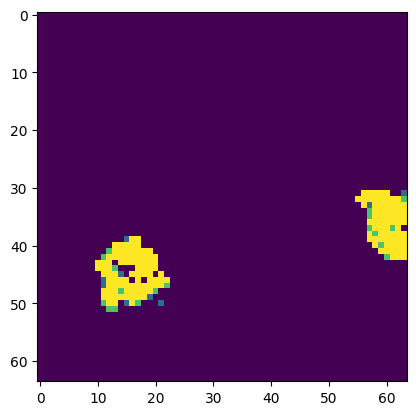

In [22]:
plt.imshow(x[0, 21, :])